In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [2]:
import utils.config as config
importlib.reload(config)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *

In [3]:
q = convert_df_to_datetime(pd.read_csv('../../data/discharge/calibration_discharge_2017_2020.csv'), 'datetime')
q['dQ_dt'] = np.gradient(q['m3/d'], q['datetime'].astype('int64')/(1e9*60*60*24))
q['segment_marker'] = (q['dQ_dt'].shift(1) * q['dQ_dt'] < 0) & (abs(q.dQ_dt) > q['m3/d'].rolling(window = 7).mean().mean()*0.1)

# q['d2Q_dt2'] = (q['dQ_dt'].diff()) / (q['datetime'].diff().dt.days)

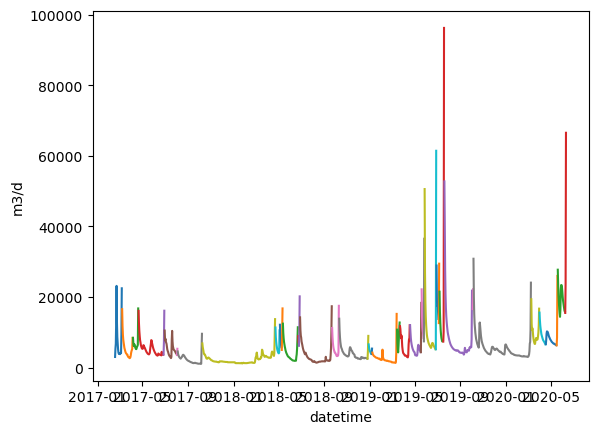

In [ ]:
idx = np.where(q.segment_marker)[0]
alpha = pd.DataFrame(columns = ['start_date', 'end_date', 'Q', 'dQ_dt', 'alpha'])
for i in range(1, len(idx)):
    start_date = q.iloc[idx[i-1]]['datetime']
    end_date = q.iloc[idx[i]]['datetime']
    Q = q.iloc[idx[i-1]:idx[i]]['m3/d'].mean()
    dQ_dt = q.iloc[idx[i-1]:idx[i]]['dQ_dt'].mean()
    
    alpha_value = np.log(q.iloc[idx[i-1]]['m3/d']/q.iloc[idx[i]]['m3/d']) / ((end_date - start_date).days * 0.4343)
    alpha.loc[alpha.shape[0]] = {'start_date': start_date, 'end_date': end_date, 'Q': Q, 'dQ_dt': dQ_dt, 'alpha': alpha_value}
    sns.lineplot(q.iloc[idx[i-1]:idx[i]], x = 'datetime', y = 'm3/d')


In [195]:
q_recession = pd.merge(q[q.dQ_dt < 0.001], pd.date_range(start=q.datetime.min(), end=q.datetime.max(), freq='D').to_frame(name='datetime'), on='datetime', how='right').sort_values('datetime').reset_index(drop=True)
q_recession['alpha'] = np.log(q_recession['m3/d'].diff())/(q_recession.datetime.diff().dt.days*0.4343)

<Axes: xlabel='datetime', ylabel='alpha'>

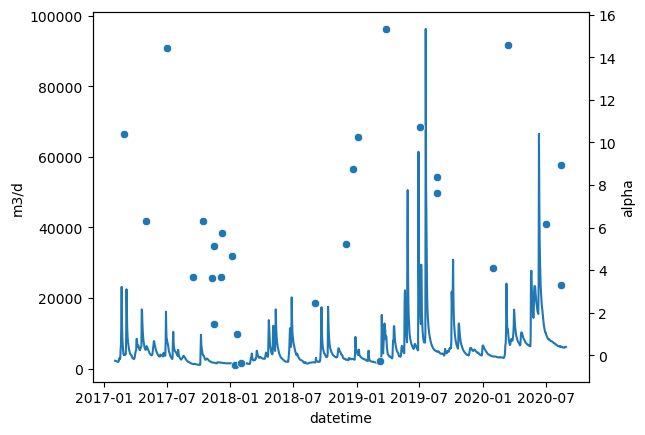

In [190]:
fig, ax = plt.subplots()
twin_ax = ax.twinx()
sns.lineplot(q, x = 'datetime', y = 'm3/d', ax=ax)
sns.scatterplot(q_recession, x='datetime', y='alpha', ax=twin_ax)


# ET and precip calculations

In [200]:
p = convert_df_to_datetime(pd.read_csv('../../../precipitation/rochester_intl_airport/precip_2017_2020.csv'), "DATE")[['DATE', 'PRCP_in', 'TAVG']]
p['PRCP_m'] = p['PRCP_in'] * 0.0254

In [216]:
fluxnet = pd.read_csv("../../../ET/ameriflux_ro5_fluxnet/AMF_US-Ro5_FLUXNET_SUBSET_DD_2017-2024_5-7.csv")
fluxnet['datetime'] = [f"{date[:4]}-{date[4:6]}-{date[6:8]}" for date in fluxnet["TIMESTAMP"].astype(str)]
fluxnet = fluxnet[(fluxnet['LE_CORR'] > -9999)]
fluxnet = convert_df_to_datetime(fluxnet, 'datetime')
fluxnet["ET_mm_d"] = fluxnet["LE_CORR"]/2.45e6  *86400
daily_ET = fluxnet[['datetime', 'ET_mm_d']]

In [ ]:
# old ET processing
# ET = pd.read_csv('../../../ET/ameriflux_ro5/AMF_US-Ro5_BASE_HH_28-5.csv', skiprows=2)
# ET['datetime'] = [f"{date[:4]}-{date[4:6]}-{date[6:8]} {date[8:10]}:{date[10:12]}" for date in ET["TIMESTAMP_START"].astype(str)]
# ET['datetime_end'] = [f"{date[:4]}-{date[4:6]}-{date[6:8]} {date[8:10]}:{date[10:12]}" for date in ET["TIMESTAMP_END"].astype(str)]
# ET = ET[(ET['LE'] > -9999) & (ET['SLE'] > -9999)]
# ET = convert_df_to_datetime(ET, 'datetime')
# ET = convert_df_to_datetime(ET, 'datetime_end')
# ET['LE_CORR'] = ET.LE + ET.SLE
# ET['ET_mm_s'] = ET.LE_CORR/2.45e6 
# ET['ET_mm_interval'] = ET['ET_mm_s'] * ((ET['datetime_end'] - ET['datetime']).dt.total_seconds())
# ET['ET_mm_d'] = ET.groupby(ET['datetime'].dt.date)['ET_mm_interval'].transform('sum')
# daily_ET = convert_df_to_datetime(ET['ET_mm_d'].groupby(ET['datetime'].dt.date).mean().reset_index(), 'datetime')
# # daily_ET.to_csv('../../../ET/clean_ET/ro5_ET_daily_2017_2025.csv', index = False)

In [217]:
p_ET = pd.merge(p, daily_ET, left_on=p.DATE.dt.date, right_on=daily_ET.datetime.dt.date, how='left')[['DATE', 'PRCP_m', 'ET_mm_d']]
p_ET['p_minus_ET_m'] = p_ET['PRCP_m'] - p_ET['ET_mm_d']/1000
p_ET['r_0'] = p_ET['p_minus_ET_m'].apply(lambda x: max(0, x))

In [220]:
p_ET['r_0'].mean()/p_ET['PRCP_m'].mean()

np.float64(0.8689848473183662)

(array([17532., 17563., 17591., 17622., 17652., 17683., 17713., 17744.,
        17775., 17805., 17836., 17866.]),
 [Text(17532.0, 0, '2018-01'),
  Text(17563.0, 0, '2018-02'),
  Text(17591.0, 0, '2018-03'),
  Text(17622.0, 0, '2018-04'),
  Text(17652.0, 0, '2018-05'),
  Text(17683.0, 0, '2018-06'),
  Text(17713.0, 0, '2018-07'),
  Text(17744.0, 0, '2018-08'),
  Text(17775.0, 0, '2018-09'),
  Text(17805.0, 0, '2018-10'),
  Text(17836.0, 0, '2018-11'),
  Text(17866.0, 0, '2018-12')])

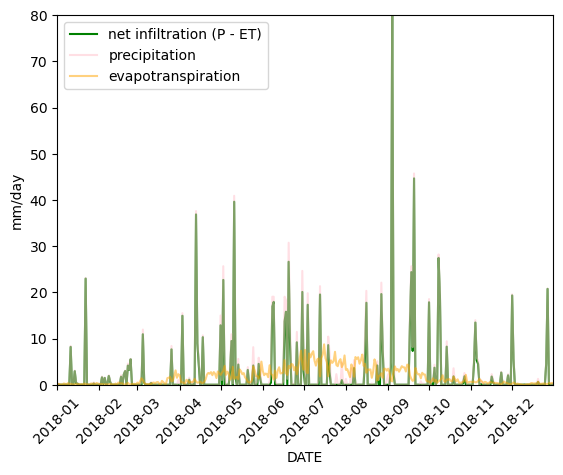

In [442]:
fig, ax = plt.subplots()
# twin_ax = ax.twinx()
sns.lineplot(p_ET , x='DATE', y=p_ET['r_0'] * 1000, ax=ax, color = 'green', label = 'net infiltration (P - ET)')
sns.lineplot(p_ET , x='DATE', y=p_ET['PRCP_m']*1000, ax=ax,  label = 'precipitation', alpha =0.5, color = 'pink')
sns.lineplot(p_ET , x='DATE', y='ET_mm_d', ax=ax,  label = 'evapotranspiration', alpha =0.5, color = 'orange')
plt.xlim(pd.to_datetime('2018-01-01'), pd.to_datetime('2018-12-31'))
plt.ylim(0,80)
plt.ylabel('mm/day')
plt.xticks(rotation=45)
# sns.lineplot(q , x='datetime', y='m3/d', ax=twin_ax)

In [64]:
h = convert_df_to_datetime(pd.read_csv("../../../gw_level/MRSW_head_2016_2025.csv"), "datetime")
h = h[(h.datetime >= pd.to_datetime("2017-01-01")) & (h.datetime < pd.to_datetime("2021-01-01"))]
h = h.groupby(h.datetime.dt.date)[['head_ft']].mean().reset_index()
h = convert_df_to_datetime(h, "datetime")
h['dh_dt'] = h['head_ft'].diff()/h.datetime.diff().dt.days

In [7]:
r = convert_df_to_datetime(pd.read_csv('../../data/recharge/2018_recharge_zixuan.csv'), "DATE")
r['m3/d'] = r['RCH[m3/s]'] *86400

(array([17683., 17690., 17697., 17704., 17713., 17720., 17727., 17734.,
        17744.]),
 [Text(17683.0, 0, '2018-06-01'),
  Text(17690.0, 0, '2018-06-08'),
  Text(17697.0, 0, '2018-06-15'),
  Text(17704.0, 0, '2018-06-22'),
  Text(17713.0, 0, '2018-07-01'),
  Text(17720.0, 0, '2018-07-08'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17734.0, 0, '2018-07-22'),
  Text(17744.0, 0, '2018-08-01')])

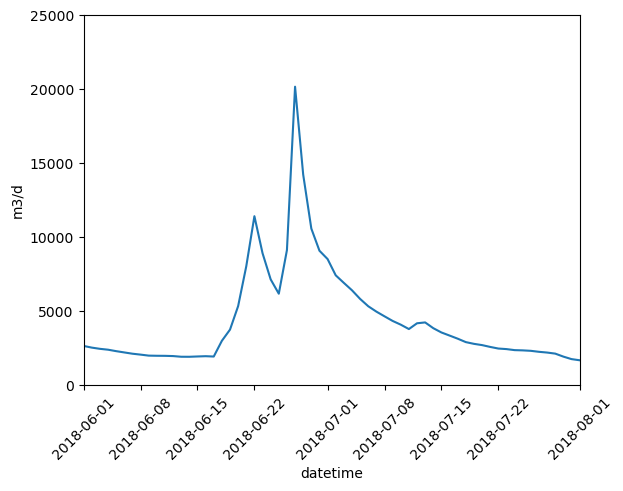

In [ ]:
sns.lineplot(q, x = 'datetime', y = 'm3/d')
plt.xlim(pd.to_datetime("2018-06-01"), pd.to_datetime("2018-08-01"))
plt.ylim(0, 25000)
plt.xticks(rotation=45)

<Axes: xlabel='DATE', ylabel='m3/d'>

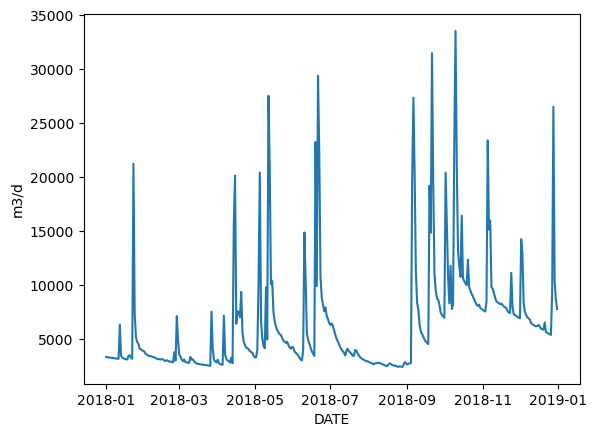

In [11]:
sns.lineplot(r, x = 'DATE', y = 'm3/d')

## Flow partitioning

In [60]:
baseflow = q['m3/d'].rolling(window = 7).mean().mean()
q_b = q[q['m3/d'] <= baseflow]

<Axes: xlabel='datetime', ylabel='m3/d'>

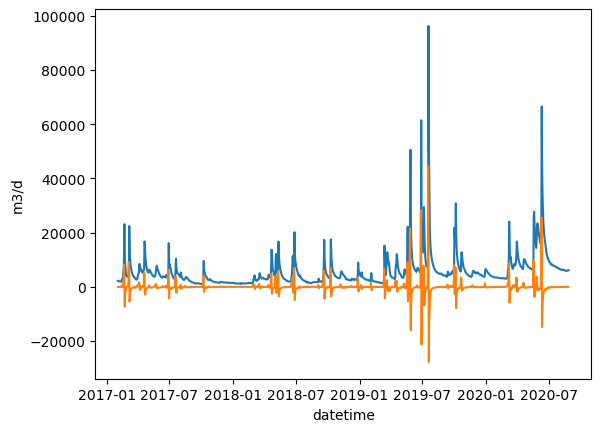

In [66]:
sns.lineplot(q, y = 'm3/d', x = 'datetime')
sns.lineplot(q, y = 'dQ_dt', x = 'datetime')

## Simple recharge partitioning

Using the model from Geyer et al. (2007)

$V_l(t) = \frac{Q_l(t)}{\alpha_l} = V_l(t - \Delta t) - [\alpha_l V_l(t - \Delta t) + R_l(t) ]\Delta t$

$V_h(t) = \frac{Q_h(t)}{\alpha_h} = V_h(t - \Delta t) - [\alpha_h V_h(t - \Delta t) + (R_h(t) + Q_l(t))] \Delta t$ 

In [3]:
def diffuse_soil_percolation(P, ET, t, S_max, theta_init, k, n, dt_unit = 'D'):
    #k = percolation coefficient (1/t)
    #n = fraction of direct recharge
    #theta_init = initial soil moisture content (0-1)
    #S_max = maximum soil moisture storage (L)
    #P = precipitation (L/t)
    #ET = evapotranspiration (L/t)
    dt_conversion = {'S': 1, 'M': 60, 'H': 3600, 'D': 86400}
    nt = len(t)
    results = pd.DataFrame(columns = ['date', 'S_m', 'R_o_m'])
    S = np.zeros(nt)
    R = np.zeros(nt)
    S[0] = theta_init * S_max
    for ts in range(1, nt):
        dt = (t[ts] - t[ts-1]).total_seconds()/dt_conversion[dt_unit]
        S_t = max(0, S[ts-1] + ((1-n)*P[ts] - ET[ts]) * dt)
        R[ts] = max(0, S_t - S_max) + k*S_t* dt
        S[ts] = max(0, S_t - R[ts])
    results ['date'] = t
    results ['S_m'] = S
    results ['R_o_m'] = R
    results['R_h_m'] = n * P
    return results

In [4]:
p = convert_df_to_datetime(pd.read_csv('../../../precipitation/rochester_intl_airport/precip_2017_2020.csv'), "DATE")[['DATE', 'PRCP_in', 'TAVG']]
p['PRCP_m'] = p['PRCP_in'] * 0.0254
ET = convert_df_to_datetime(pd.read_csv('../../../ET/clean_ET/ro5_fluxnet_ET_2017_2024.csv'), 'datetime')
p_ET = pd.merge(p, ET, left_on=p.DATE.dt.date, right_on=ET.datetime.dt.date, how='left')[['DATE', 'PRCP_m', 'ET_mm_d']]
p_ET['p_minus_ET_m'] = p_ET['PRCP_m'] - p_ET['ET_mm_d']/1000
p_ET['r_0'] = p_ET['p_minus_ET_m'].apply(lambda x: max(0, x))
q = convert_df_to_datetime(pd.read_csv('../../data/discharge/calibration_discharge_2017_2020.csv'), 'datetime')
p_ET = p_ET[(p_ET.DATE >= pd.to_datetime('2018-05-01')) & (p_ET.DATE < pd.to_datetime('2018-07-01'))].reset_index(drop=True)
q = q[(q.datetime >= pd.to_datetime('2018-05-01')) & (q.datetime < pd.to_datetime('2018-07-01'))]

In [5]:
mean_r0 = p_ET.r_0.mean()

In [7]:
S_max = 1
theta_init = 0.0
k = 0.1
n = 0.1
A = 4629284 #m^2


In [8]:
R_o = diffuse_soil_percolation(p_ET['PRCP_m'], p_ET['ET_mm_d']/1000, p_ET['DATE'], S_max = S_max, theta_init = theta_init, k = k, n = n)
R_o[['R_o (m3/d)', 'R_h (m3/d)']] = R_o[['R_o_m', 'R_h_m']] * A
R_o.to_csv(f'recharge/soil_balance_model_Smax_{S_max}_k_{k}_n_{n}_theta_{theta_init}.csv')

Text(0, 0.5, 'R (mm/d)')

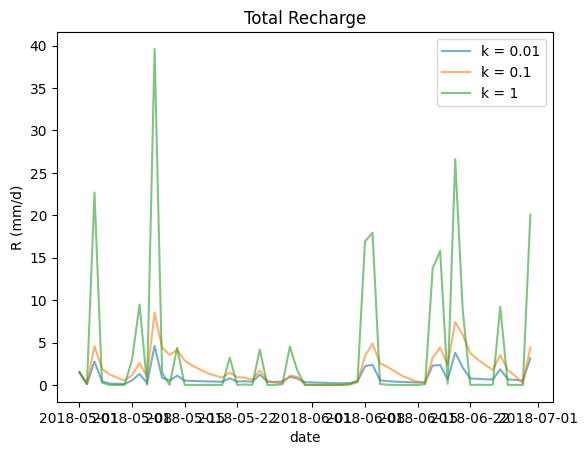

In [68]:
fig, ax = plt.subplots()#1,3, gridspec_kw={'wspace' : 0}, sharey=True, figsize = (12,4)
for i, k in enumerate([.01, .1, 1]):
    R_o = diffuse_soil_percolation(p_ET['PRCP_m'], p_ET['ET_mm_d']/1000, p_ET['DATE'], S_max = S_max, theta_init = theta_init, k = k, n = n)
    R_o[['R_o (m3/d)', 'R_h (m3/d)']] = R_o[['R_o_m', 'R_h_m']] * A
    sns.lineplot(R_o, x='date', y=(R_o['R_o_m'] + R_o['R_h_m']) * 1000,  label = f'k = {k}', alpha = 0.6, ax =ax)
    # sns.lineplot(R_o, x='date', y=R_o['S_m'] * 1000,  label = f'k = {k}', alpha = 0.6, ax=ax[1])
    # ax[i].bar(R_o['date'], R_o['R_o (m3/d)'], label = 'diffuse recharge', color = 'blue', alpha = 0.6)
    # ax[i].bar(R_o['date'], R_o['R_h (m3/d)'], bottom=R_o['R_o (m3/d)'], label = 'quick recharge', color = 'orange', alpha = 0.6)
plt.title("Total Recharge")
ax.set_ylabel("R (mm/d)")
    # R_o.to_csv(f'recharge/soil_balance_model_Smax_{S_max}_k_{k}_n_{n}_theta_{theta_init}.csv')

Text(0, 0.5, 'Discharge and Recharge (m3/d)')

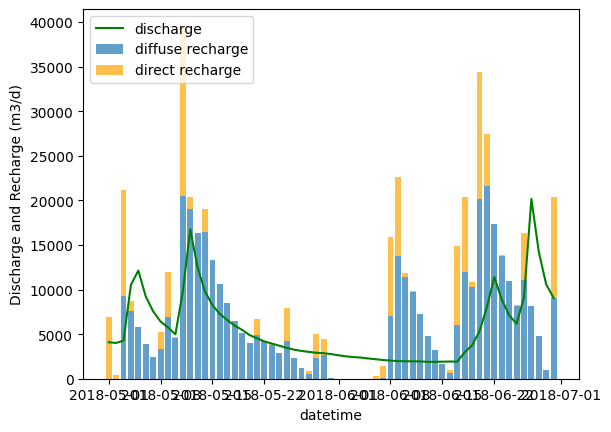

In [11]:
fig, ax = plt.subplots()
start_date = pd.to_datetime("2018-05-01")
end_date = pd.to_datetime("2018-07-01")
temp_R = R_o[(R_o['date'] >= start_date) & (R_o['date'] <= end_date)]
temp_q = q[(q['datetime'] >= start_date) & (q['datetime'] <= end_date)]
ax.bar(temp_R['date'], temp_R['R_o (m3/d)'],  label = 'diffuse recharge', alpha =0.7)    
ax.bar(temp_R['date'], temp_R['R_h (m3/d)'], color = 'orange', alpha  = 0.7, bottom = temp_R['R_o (m3/d)'], label = 'direct recharge')
sns.lineplot(temp_q, x = 'datetime', y = 'm3/d', ax = ax, color = 'green', label = 'discharge')
ax.legend(loc='upper left')
ax.set_ylabel('Discharge and Recharge (m3/d)')


Text(0, 0.5, 'Discharge and Recharge (m3/d)')

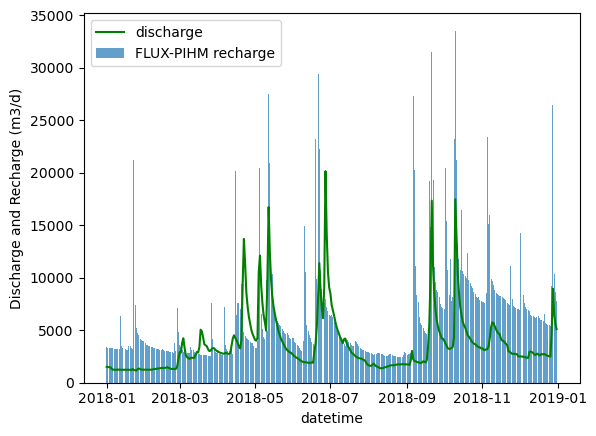

In [429]:
fig, ax = plt.subplots()
start_date = pd.to_datetime("2018-01-01")
end_date = pd.to_datetime("2018-12-31")
temp_R = r[(r['DATE'] >= start_date) & (r['DATE'] <= end_date)]
temp_q = q[(q['datetime'] >= start_date) & (q['datetime'] <= end_date)]
ax.bar(temp_R['DATE'], temp_R['m3/d'],  label = 'FLUX-PIHM recharge', alpha =0.7)    
ax.legend(loc='center left', bbox_to_anchor=(1.2, 0.5))
sns.lineplot(temp_q, x = 'datetime', y = 'm3/d', ax = ax, color = 'green', label = 'discharge')
ax.set_ylabel('Discharge and Recharge (m3/d)')

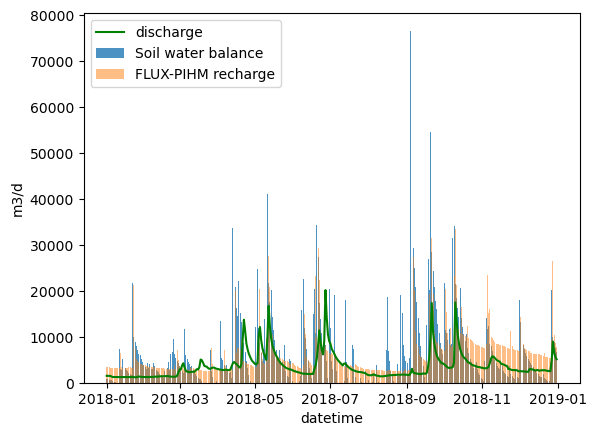

In [438]:
fig, ax = plt.subplots()
temp_R = R_o[(R_o['date'] >= start_date) & (R_o['date'] <= end_date)]
ax.bar(temp_R['date'], temp_R['R_o (m3/d)'] + temp_R['R_h (m3/d)'] ,  label = 'Soil water balance', alpha =0.8)
ax.bar(r['DATE'], r['m3/d'],  label = 'FLUX-PIHM recharge', alpha =0.5)    
sns.lineplot(temp_q, x = 'datetime', y = 'm3/d', ax = ax, color = 'green', label = 'discharge')
plt.legend()    


In [6]:
def linear_reservoir_model(R_l, R_h, t, alpha_l, alpha_h, **params):
    nt = len(t)
    dt_unit = params.get('dt_unit', 'D')
    time_conversion = {'S': 1, 'M': 60, 'H': 3600, 'D': 86400}
    V_l = np.zeros(nt)
    V_l[0] = params.get('V_l0', 0.0)
    V_h = np.zeros(nt)
    V_h[0] = params.get('V_h0', 0.0)
    Q_l = np.zeros(nt)
    Q_h = np.zeros(nt)
    for i in range(1, nt):
        R_l_t = R_l[i]
        R_h_t = R_h[i]
        dt = (t[i] - t[i - 1]).total_seconds()/time_conversion[dt_unit]
        V_l[i] = V_l[i - 1] + (-1* alpha_l * V_l[i - 1] + R_l_t) * dt
        Q_l[i] = alpha_l * V_l[i]
        V_h[i] = V_h[i - 1] + (-1* alpha_h * V_h[i - 1] + R_h_t + Q_l[i]) * dt
        Q_h[i] = alpha_h * V_h[i]
    return Q_l, Q_h, V_l, V_h 

In [ ]:
def linear_reservoir_fractures_model(R_l, R_h, t, alpha_l, alpha_f, alpha_h, **params):
    ## TODO: implement fracture reservoir
    nt = len(t)
    dt_unit = params.get('dt_unit', 'D')
    time_conversion = {'S': 1, 'M': 60, 'H': 3600, 'D': 86400}
    V_l = np.zeros(nt)
    V_l[0] = params.get('V_l0', 0.0)
    V_h = np.zeros(nt)
    V_h[0] = params.get('V_h0', 0.0)
    Q_l = np.zeros(nt)
    Q_h = np.zeros(nt)
    for i in range(1, nt):
        R_l_t = R_l[i]
        R_h_t = R_h[i]
        dt = (t[i] - t[i - 1]).total_seconds()/time_conversion[dt_unit]
        V_l[i] = V_l[i - 1] + (-1* alpha_l * V_l[i - 1] + R_l_t) * dt
        Q_l[i] = alpha_l * V_l[i]
        V_h[i] = V_h[i - 1] + (-1* alpha_h * V_h[i - 1] + R_h_t + Q_l[i]) * dt
        Q_h[i] = alpha_h * V_h[i]
    return Q_l, Q_h, V_l, V_h 

In [7]:
def conduit_activation(R_l, R_h, t, alpha_l_0, alpha_l_1, alpha_h, V_max, **params):
    """
     Conduit activation linear reservoir model
     alpha_l_0: recession coefficent for h < h_max (inactive conduit)
     alpha_l_1 : recession coefficent for h >= h_max (active conduit)
     V_max: threshold volume for conduit activation (can convert to head by doing V/A)"""

    nt = len(t)
    dt_unit = params.get('dt_unit', 'D')
    time_conversion = {'S': 1, 'M': 60, 'H': 3600, 'D': 86400}
    V_l = np.zeros(nt)
    V_l[0] = params.get('V_l0', 0.0)
    V_h = np.zeros(nt)
    V_h[0] = params.get('V_h0', 0.0)
    Q_l = np.zeros(nt)
    Q_h = np.zeros(nt)
    conduit_active = np.zeros(nt, dtype=bool)
    for i in range(1, nt):
        R_l_t = R_l[i]
        R_h_t = R_h[i]
        dt = (t[i] - t[i - 1]).total_seconds()/time_conversion[dt_unit]
        V_l[i] = V_l[i - 1] + (-1* alpha_l * V_l[i - 1] + R_l_t) * dt
        Q_l[i] = alpha_l * V_l[i]
        if V_l[i] >= V_max:
            conduit_active[i] = True
            V_h[i] = V_h[i - 1] + (-1* alpha_h * V_h[i - 1] + R_h_t + Q_l[i]) * dt
        else:
            V_h[i] = V_h[i - 1] + (-1* alpha_h * V_h[i - 1] + Q_l[i]) * dt
        Q_h[i] = alpha_h * V_h[i]
    return Q_l, Q_h, conduit_active

In [8]:
def full_model(P, ET, t, **params):
    n = params.get('n', 0.3)
    S_max = params.get('S_max', 0.3)
    theta_init = params.get('theta_init', 0.2)
    k = params.get('k', 0.1)
    alpha_l = params.get('alpha_l', 0.1)
    alpha_h = params.get('alpha_h', 0.01)
    dt_unit = params.get('dt_unit', 'D')
    V_l0 = params.get('V_l0', 0.0)
    V_h0 = params.get('V_h0', 0.0)
    R_h = P * n * A
    results = diffuse_soil_percolation(P, ET, t, S_max = S_max, theta_init = theta_init, k = k, n = n)
    R_l = results['R_o_m'] * A
    Q_l, Q_h, V_l, V_h = linear_reservoir_model(R_l, R_h, t, alpha_l, alpha_h, dt_unit=dt_unit, V_l0=V_l0, V_h0=V_h0)
    results['Q_l'] = Q_l
    results['Q_h'] = Q_h
    results['V_l'] = V_l
    results['V_h'] = V_h
    results['R_h (m3/d)'] = R_h
    return results


## Spin up Period
Run the model with a constant R (calibrated from mean recharge rate) for 100 days to reach steady state. Match Q_l with bear spring baseflow. Use the final V_l and V_h as initial conditions for transient run. 

In [9]:
#bear spring aquifer parameters-- from Barry et al. (2019) and Soucey (2025)
A = 4629284 #m^2
d = 35 # m 
n =.01 #effective porosity
V_l = 0 #m^3

In [10]:
S_max = .3
theta_init = 0.0
k = 0.07
n = 0.3
alpha_l = 0.14
alpha_h = 0.4
ss_P = np.full(200, mean_r0/5)
ss_ET = np.full(200, 0)
ss_dates = pd.date_range(start="2024-01-01", periods=200, freq="D") #doesn't actually matter which dates since this is just spin up 

out = full_model(ss_P, ss_ET, ss_dates, n=n, S_max=S_max, theta_init=theta_init, k=k, alpha_l=alpha_l, alpha_h=alpha_h, dt_unit='D')
V_l0 = out['V_l'].iloc[-1]
V_h0 = out['V_h'].iloc[-1]

Text(0.5, 1.0, 'Steady-state spin up of linear reservoir model')

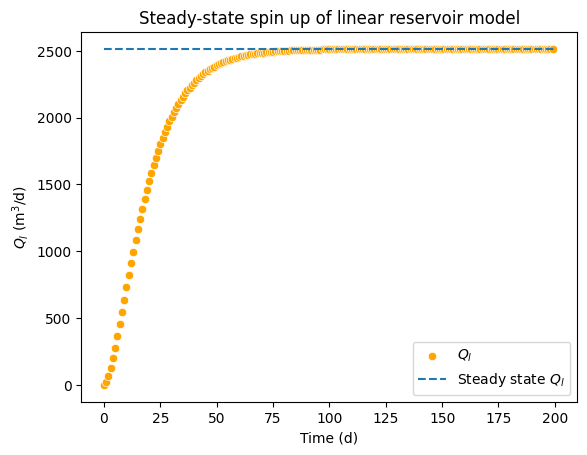

In [11]:
sns.scatterplot(out, x = range(len(out)), y='Q_l', label = r'$Q_l$', color = 'orange')
plt.ylabel(r'$Q_l$ (m$^3$/d)')
plt.xlabel("Time (d)")
plt.hlines(y = out['Q_l'].max(), xmin = 0, xmax = len(out), linestyles = 'dashed', label = r'Steady state $Q_l$')
# sns.scatterplot(out, x='date', y='V_l', label = 'V_l', color = 'green')
# sns.scatterplot(out, x='date', y='V_h', label = 'V_h', color = 'red')
plt.legend(loc = 'lower right')
plt.title("Steady-state spin up of linear reservoir model")


In [15]:
out.Q_l.max()/86400

np.float64(0.02909692564588181)

In [80]:
S_max = .3
theta_init = 0.0
k = 0.07
n = 0.3
alpha_l = 0.14
alpha_h = 0.4
out = full_model(p_ET['PRCP_m'], p_ET['ET_mm_d']/1000, p_ET['DATE'], n=n, S_max=S_max, theta_init=theta_init, k=k, alpha_l=alpha_l, alpha_h=alpha_h, dt_unit='D', V_l0=V_l0, V_h0=V_h0)


<Axes: xlabel='date', ylabel='Q_h'>

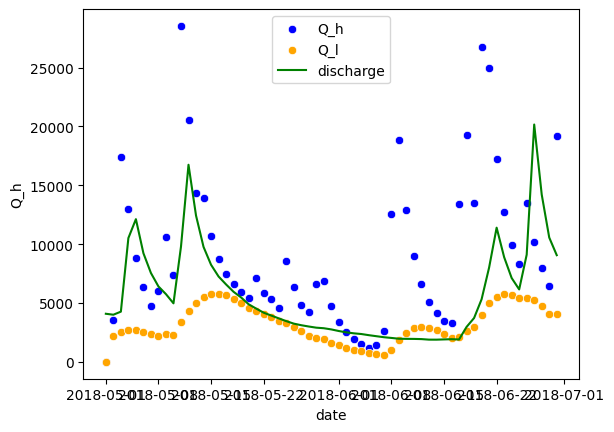

In [82]:
sns.scatterplot(out, x='date', y='Q_h', label = 'Q_h', color = 'blue')
sns.scatterplot(out, x='date', y='Q_l', label = 'Q_l', color = 'orange')
# sns.lineplot(out, x='date', y=out['Q_h'] + out['R_h (m3/d)'], label = 'Q_l + R_h', color = 'purple')
sns.lineplot(q, x='datetime', y='m3/d', label = 'discharge', color = 'green')

In [ ]:
def objective(S_max, k, n , alpha_l): 
    out = full_model(p_ET['PRCP_m'], p_ET['ET_mm_d']/1000, p_ET['DATE'], n=n, S_max=S_max, theta_init=theta_init, k=k, alpha_l=alpha_l, alpha_h=alpha_h, dt_unit='D')
    simulated_Q = out['Q_l'] + out['R_h (m3/d)'] 
    observed_Q = q.loc[simulated_Q.index]['m3/d']
    rmse = np.sqrt(np.mean((simulated_Q - observed_Q)**2))
    return rmse

Text(0.5, 1.0, 'Sensitivity Analysis')

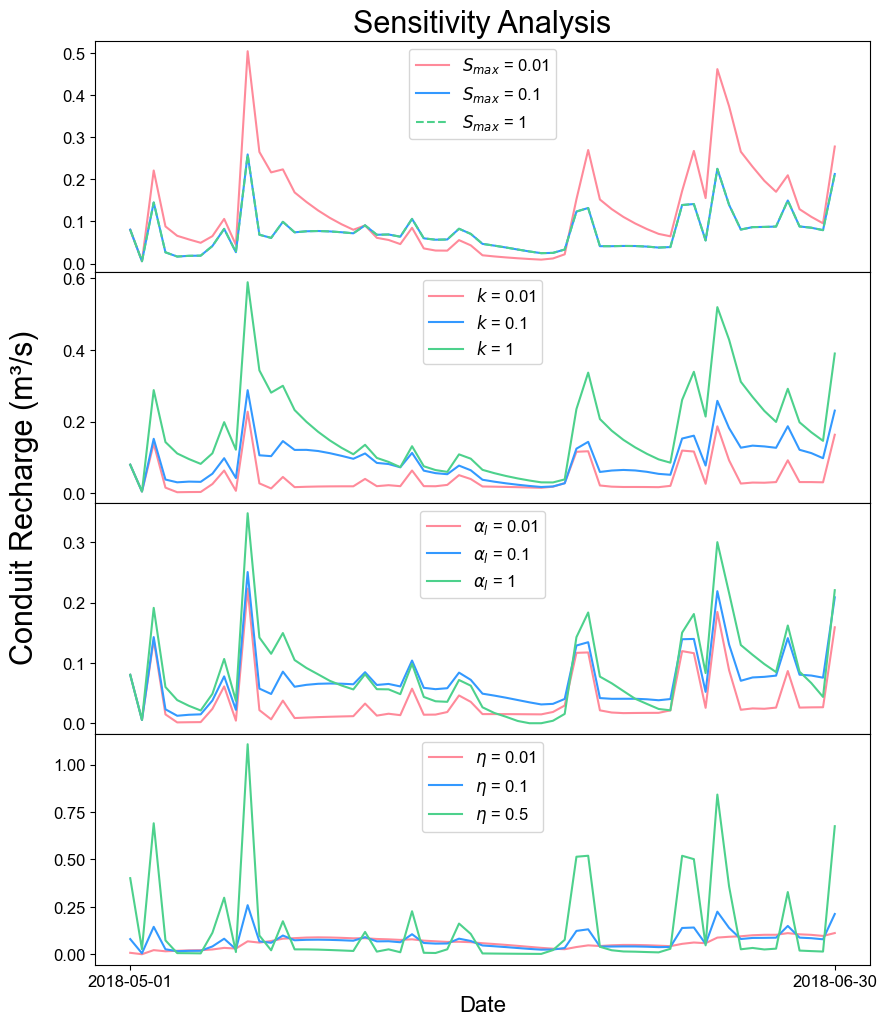

In [200]:
fig, ax = plt.subplots(4, 1, sharex=True, gridspec_kw= {'hspace': 0.0}, figsize = (10, 12))
palette = {
    0.01: '#FF8A9A',  # bright pink (unchanged)
    0.1:  '#3399FF',  # more saturated blue
    0.5:    '#4DD18C',   # more saturated, but still soft green
    1:    '#4DD18C'   # more saturated, but still soft green
}
S_max = .3
theta_init = 0.0
k = 0.05
n = 0.1
alpha_l = 0.14
alpha_h = 0.4
for S_max in [0.01, 0.1, 1]:
    out = full_model(p_ET['PRCP_m'], p_ET['ET_mm_d']/1000, p_ET['DATE'], n=n, S_max=S_max, theta_init=theta_init, k=k, alpha_l=alpha_l, alpha_h=alpha_h, dt_unit='D')
    sns.lineplot(x = out['date'], y = (out['Q_l'] + out['R_h (m3/d)'])/86400, label = rf'$S_{{max}}$ = {S_max}', ax = ax[0], color = palette[S_max], linestyle = '--' if S_max == 1 else '-')
ax[0].legend()
ax[0].set_ylabel('')

S_max = .3
theta_init = 0.0
k = 0.05
n = 0.1
alpha_l = 0.14
alpha_h = 0.4
for k in [0.01, 0.1, 1]:
    out = full_model(p_ET['PRCP_m'], p_ET['ET_mm_d']/1000, p_ET['DATE'], n=n, S_max=S_max, theta_init=theta_init, k=k, alpha_l=alpha_l, alpha_h=alpha_h, dt_unit='D')
    sns.lineplot(x = out['date'], y = (out['Q_l'] + out['R_h (m3/d)'])/86400, label = rf'$k$ = {k}', ax = ax[1], color = palette[k])
ax[1].legend(loc = 'upper center')
ax[1].set_ylabel('')
S_max = .3
theta_init = 0.0
k = 0.05
n = 0.1
alpha_l = 0.14
alpha_h = 0.4
for alpha_l in [0.01, 0.1, 1]:
    out = full_model(p_ET['PRCP_m'], p_ET['ET_mm_d']/1000, p_ET['DATE'], n=n, S_max=S_max, theta_init=theta_init, k=k, alpha_l=alpha_l, alpha_h=alpha_h, dt_unit='D')
    sns.lineplot(x = out['date'], y = (out['Q_l'] + out['R_h (m3/d)'])/86400, label = rf'$\alpha_l$ = {alpha_l}', ax = ax[2], color = palette[alpha_l])
ax[2].legend(loc = 'upper center')
ax[2].set_ylabel('')

S_max = .3
theta_init = 0.0
k = 0.05
n = 0.1
alpha_l = 0.14
alpha_h = 0.4
for n in [0.01, 0.1, .5]:
    out = full_model(p_ET['PRCP_m'], p_ET['ET_mm_d']/1000, p_ET['DATE'], n=n, S_max=S_max, theta_init=theta_init, k=k, alpha_l=alpha_l, alpha_h=alpha_h, dt_unit='D')
    sns.lineplot(x = out['date'], y = (out['Q_l'] + out['R_h (m3/d)'])/86400, label = rf'$\eta$ = {n}', ax = ax[3], color = palette[n])
ax[3].legend(loc = 'upper center')
ax[3].set_ylabel('')

fig.text(0.04, 0.5, 'Conduit Recharge (m³/s)', va='center', rotation='vertical', fontsize=22)
plt.xlabel("Date")
ax[3].set_xticks([out['date'].min(), out['date'].max()])
ax[0].set_title("Sensitivity Analysis")


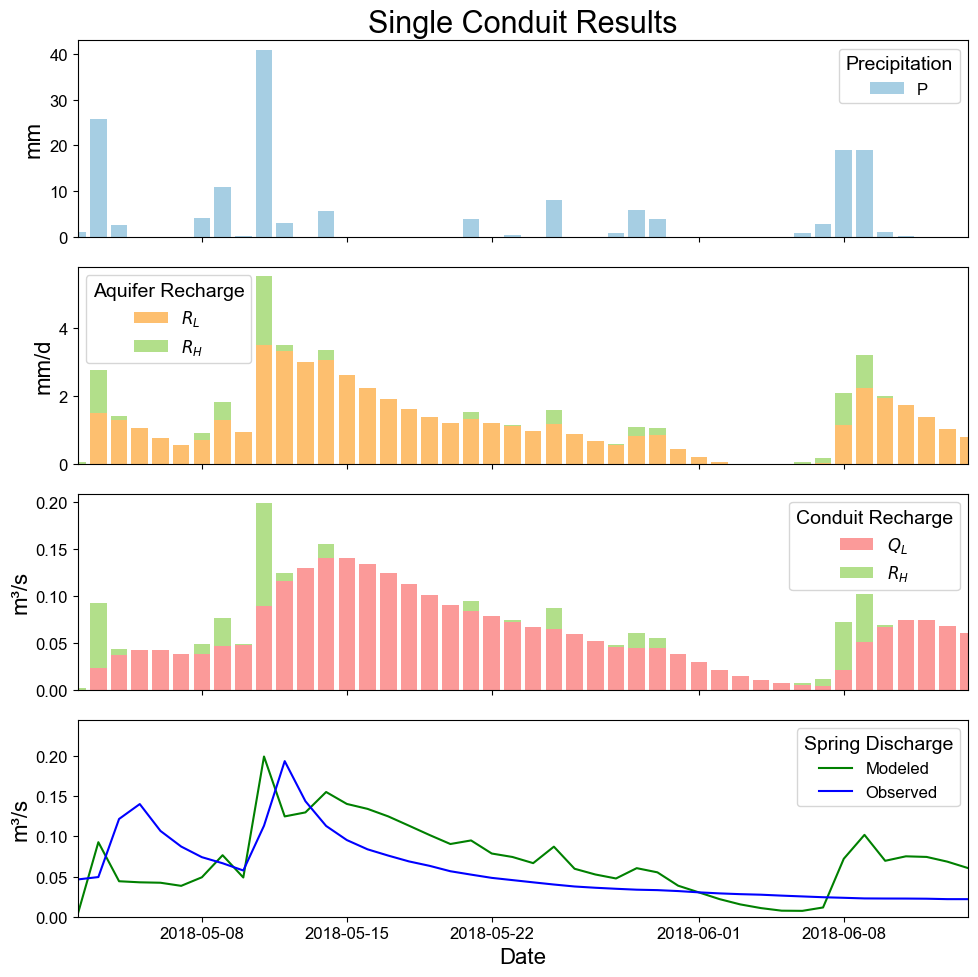

In [12]:
colors = {
    'precip':  '#A6CEE3',   # pastel blue
    'R_L':     '#FDBF6F',   # pastel orange
    'R_H':     '#B2DF8A',   # pastel green
    'Q_L':     '#FB9A99',   # pastel coral/red
    'Q_H':     '#CAB2D6',   # pastel purple
    'modeled': '#80CDC1',   # pastel teal
    'observed':'#5DA5DA'    # pastel navy
}

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14            # main text size
plt.rcParams['axes.labelsize'] = 16       # axis labels
plt.rcParams['axes.titlesize'] = 22       # title
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

fig, ax = plt.subplots(4,1, sharex=True, figsize = (10,10))
ax[0].bar(p_ET['DATE'], p_ET['PRCP_m']*1000, color = colors['precip'], label = 'P')
ax[0].set_ylabel('mm')
ax[0].legend(title = 'Precipitation', loc = 'upper right')
ax[1].bar(out['date'], out['R_o_m']*1000, color = colors['R_L'], label = r'$R_L$')
ax[1].bar(out['date'], out['R_h_m']*1000, bottom = out['R_o_m']*1000, color = colors['R_H'], label = r'$R_H$')
ax[1].set_ylabel(r'mm/d')
ax[1].legend(title = 'Aquifer Recharge')
ax[2].bar(out['date'], out['Q_l']/86400, color = colors['Q_L'], label = r'$Q_L$')
ax[2].bar(out['date'], out['R_h (m3/d)']/86400, bottom = out['Q_l']/86400, color = colors['R_H'], label = r'$R_H$')
ax[2].set_ylabel('m³/s')
ax[2].legend(title = 'Conduit Recharge')
sns.lineplot(out, x = 'date', y = (out['Q_l'] + out['R_h (m3/d)'])/86400, ax = ax[3], color = 'green', label = 'Modeled')
# sns.lineplot(out_high_ET, x = 'date', y = (out_high_ET['Q_l'] + out_high_ET['R_h (m3/d)'])/86400, ax = ax[3], color = 'red', label = 'Modeled (High ET)')
sns.lineplot(q, x = 'datetime', y = q['m3/d']/86400, ax = ax[3], color = 'blue', label = 'Observed')
ax[3].set_ylim(0, )
ax[3].set_ylabel('m³/s')
ax[3].legend(title = 'Spring Discharge')
ax[3].set_xlabel('Date')
plt.xlim(pd.to_datetime("2018-05-02"), pd.to_datetime("2018-06-14"))
ax[0].set_title("Single Conduit Results")
plt.tight_layout()

In [485]:
out.to_csv(f'recharge/conduit_recharge_S_max_{S_max}_k_{k}_n_{n}_theta_{theta_init}_alpha_l_{alpha_l}_alpha_h_{alpha_h}.csv', index = False)

(array([17532., 17563., 17591., 17622., 17652., 17683., 17713., 17744.,
        17775., 17805., 17836., 17866.]),
 [Text(17532.0, 0, '2018-01'),
  Text(17563.0, 0, '2018-02'),
  Text(17591.0, 0, '2018-03'),
  Text(17622.0, 0, '2018-04'),
  Text(17652.0, 0, '2018-05'),
  Text(17683.0, 0, '2018-06'),
  Text(17713.0, 0, '2018-07'),
  Text(17744.0, 0, '2018-08'),
  Text(17775.0, 0, '2018-09'),
  Text(17805.0, 0, '2018-10'),
  Text(17836.0, 0, '2018-11'),
  Text(17866.0, 0, '2018-12')])

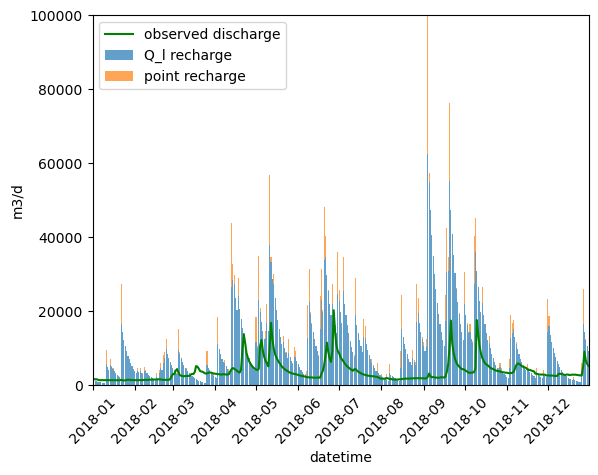

In [487]:
fig, ax = plt.subplots()
# twin_ax = ax.twinx()
# sns.lineplot(out, x = 'date', y = 'Q_h', label = 'Q_h', ax=ax)
ax.bar(out['date'], out['Q_l'], label = 'Q_l recharge', alpha =0.7)
ax.bar(out['date'], out['R_h'], bottom = out['Q_l'], label = 'point recharge', alpha = 0.7)
# sns.lineplot(out, x = 'date', y = 'R_o_m', label = 'R_l', alpha = 0.5, ax=twin_ax)
sns.lineplot(q, x = 'datetime', y = 'm3/d', label = 'observed discharge', ax=ax, color = 'green')
plt.xlim(pd.to_datetime("2018-01-01"), pd.to_datetime("2018-12-31"))
plt.ylim(0, 100000)
plt.xticks(rotation=45)

(array([17532., 17563., 17591., 17622., 17652., 17683., 17713., 17744.,
        17775., 17805., 17836., 17866.]),
 [Text(17532.0, 0, '2018-01'),
  Text(17563.0, 0, '2018-02'),
  Text(17591.0, 0, '2018-03'),
  Text(17622.0, 0, '2018-04'),
  Text(17652.0, 0, '2018-05'),
  Text(17683.0, 0, '2018-06'),
  Text(17713.0, 0, '2018-07'),
  Text(17744.0, 0, '2018-08'),
  Text(17775.0, 0, '2018-09'),
  Text(17805.0, 0, '2018-10'),
  Text(17836.0, 0, '2018-11'),
  Text(17866.0, 0, '2018-12')])

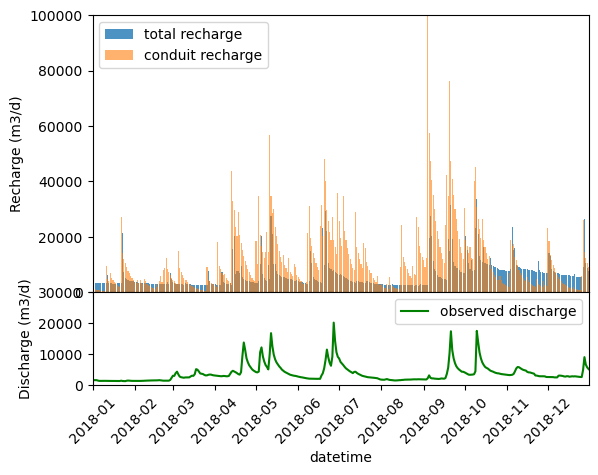

In [507]:
fig, ax = plt.subplots(2,1, gridspec_kw={'height_ratios':[3,1], 'hspace': 0}, sharex=True)
# twin_ax = ax.twinx()
# sns.lineplot(out, x = 'date', y = 'Q_h', label = 'Q_h', ax=ax)

# sns.lineplot(out, x = 'date', y = 'R_o_m', label = 'R_l', alpha = 0.5, ax=twin_ax)
sns.lineplot(q, x = 'datetime', y = 'm3/d', label = 'observed discharge', ax=ax[1], color = 'green')
ax[0].bar(r['DATE'], r['m3/d'], label = 'total recharge', alpha =0.8)
ax[0].bar(out['date'], out['R_h']+ out['Q_l'], label = 'conduit recharge', alpha = 0.6)
ax[0].legend()
ax[0].set_ylabel('Recharge (m3/d)')
ax[0].set_xlabel('Date')
ax[0].set_ylim(0, 100000)
ax[1].set_ylabel('Discharge (m3/d)')
ax[1].set_ylim(0, 30000)
plt.xlim(pd.to_datetime("2018-01-01"), pd.to_datetime("2018-12-31"))
plt.xticks(rotation=45)

In [236]:
R = pd.DataFrame(R)
R['DATE'] = p_ET['DATE']
R['R_h'] = R_h
R['Q_l'] = Q_l
R['R_conduit'] = (1-f_r) * R['r_0']
R['Q_h'] = Q_h
# R.to_csv(f'recharge/precip/2017_2020_al_{alpha_l}_ah_{alpha_h}_fr_{f_r}.csv', index = False)

Text(0.5, 1.0, 'Recharge and Discharge')

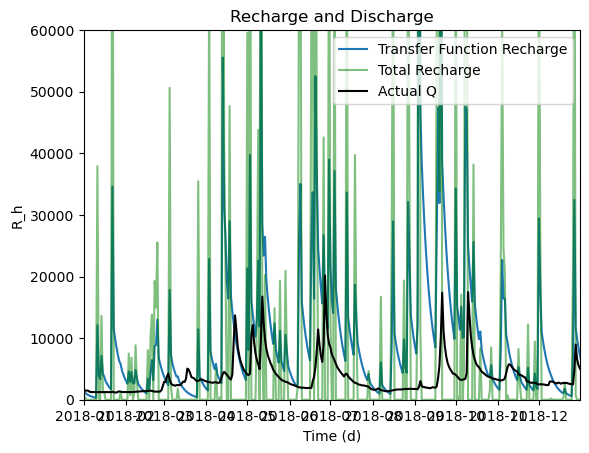

In [238]:
sns.lineplot(data = R, y ='R_h', x = 'DATE', label = 'Transfer Function Recharge')
sns.lineplot(data = R, y = 'r_0', x = 'DATE', alpha = 0.5, label = 'Total Recharge', color = 'Green')
# sns.lineplot(Q_h, label = 'Modeled Q', alpha = 0.5 )
sns.lineplot(q, y = 'm3/d', x = 'datetime', label = 'Actual Q', color = 'black')
plt.ylim(0, 60000)
plt.xlim(pd.to_datetime('2018-01-01'), pd.to_datetime('2018-12-31'))
plt.xlabel("Time (d)")
plt.title("Recharge and Discharge")

In [49]:
import numpy as np
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

# --- your model (unchanged except minor vectorization safety) ---
def linear_reservoir_model(R, dt, alpha_l, alpha_h, **params):
    """
    R : 1D array of recharge (same length as desired output), units per unit time
    dt: timestep length (same units used for alpha: e.g., days)
    alpha_l, alpha_h : recession coefficients (1/time)
    params: optional keys:
        f_r : fraction to low-flow reservoir (0..1)
        V_l0, V_h0 : initial volumes (same units as Q*1/alpha)
    Returns: Q_l, Q_h arrays (length = len(R))
    """
    R = np.asarray(R, dtype=float)
    n = len(R)
    f_r = float(params.get('f_r', 0.5))
    V_l = np.zeros(n, dtype=float)
    V_h = np.zeros(n, dtype=float)
    V_l[0] = float(params.get('V_l0', 0.0))
    V_h[0] = float(params.get('V_h0', 0.0))
    Q_l = np.zeros(n, dtype=float)
    Q_h = np.zeros(n, dtype=float)
    for t in range(1, n):
        R_l = f_r * R[t]
        R_h = (1 - f_r) * R[t]
        # explicit Euler
        V_l[t] = V_l[t - 1] - alpha_l * V_l[t - 1] * dt + R_l * dt
        Q_l[t] = alpha_l * V_l[t]
        V_h[t] = V_h[t - 1] - alpha_h * V_h[t - 1] * dt + (R_h + Q_l[t]) * dt
        Q_h[t] = alpha_h * V_h[t]
    return Q_l, Q_h

# --- metrics ---
def rmse(x, y):
    return np.sqrt(np.mean((x - y)**2))

def nash_sutcliffe(sim, obs):
    denom = np.sum((obs - np.mean(obs))**2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((obs - sim)**2) / denom

# --- calibration routine ---
def calibrate_two_reservoir(R, dt, Q_obs,
                            fit_initial_volumes=False,
                            bounds_params=None,
                            global_popsize=20,
                            verbose=True):
    """
    Calibrate alpha_l, alpha_h, f_r (and optionally V_l0, V_h0) to match observed Q_obs (Q_h).
    
    Parameters
    ----------
    R : array-like
        Recharge time series (length n)
    dt : float
        Timestep (same units used for alpha, e.g. days)
    Q_obs : array-like
        Observed target discharge (length n). Use same timestep alignment as R.
    fit_initial_volumes : bool
        If True, include V_l0 and V_h0 in parameter vector to optimize.
    bounds_params : dict or None
        Optional dictionary to override default bounds. Keys: 'alpha_l','alpha_h','f_r',
        'V_l0','V_h0' each as (low, high).
    global_popsize : int
        population size for differential_evolution
    Returns
    -------
    result dict with keys: popt (best params), rmse, nse, sim (Q_l,Q_h), and more.
    """

    R = np.asarray(R, dtype=float)
    Q_obs = np.asarray(Q_obs, dtype=float)
    n = len(R)
    assert len(Q_obs) == n, "R and Q_obs must be same length"

    # default bounds (you may want to change depending on units/time)
    # alpha bounds wide (1e-6 .. 10 per unit time). f_r in [0,1]
    b = {
        'alpha_l': (1e-8, 10.0),
        'alpha_h': (1e-8, 10.0),
        'f_r':    (0.0, 1.0),
        'V_l0':   (0.0, np.max(Q_obs)*100.0 + 1e-6),
        'V_h0':   (0.0, np.max(Q_obs)*100.0 + 1e-6)
    }
    if bounds_params:
        b.update(bounds_params)

    # parameter ordering for optimizer
    names = ['alpha_l', 'alpha_h', 'f_r']
    if fit_initial_volumes:
        names += ['V_l0', 'V_h0']

    # build bounds list for differential_evolution
    de_bounds = [b[name] for name in names]

    # objective for global optimization: minimize normalized RMSE or RMSE
    def objective_de(x):
        # map x to param dict
        p = dict(zip(names, x))
        params = {'f_r': p['f_r']}
        if fit_initial_volumes:
            params['V_l0'] = p['V_l0']
            params['V_h0'] = p['V_h0']
        _, Qh = linear_reservoir_model(R, dt, p['alpha_l'], p['alpha_h'], **params)
        # penalize negative/NaN
        if np.any(np.isnan(Qh)) or np.any(Qh < -1e6):
            return 1e6
        # Use RMSE on Qh
        return rmse(Qh, Q_obs)

    # run global optimizer
    if verbose:
        print("Running global optimization (differential evolution)...")
    de_res = differential_evolution(objective_de, de_bounds, popsize=global_popsize, polish=False, maxiter=200)
    x0 = de_res.x
    if verbose:
        print("DE best:", dict(zip(names, x0)), "obj:", de_res.fun)

    # refine with least_squares (local)
    # least_squares wants vector residuals; use robust loss
    def residuals_ls(x):
        p = dict(zip(names, x))
        params = {'f_r': p['f_r']}
        if fit_initial_volumes:
            params['V_l0'] = p['V_l0']
            params['V_h0'] = p['V_h0']
        _, Qh = linear_reservoir_model(R, dt, p['alpha_l'], p['alpha_h'], **params)
        return (Qh - Q_obs)

    # bounds for least_squares: convert to arrays
    lower = np.array([b[name][0] for name in names])
    upper = np.array([b[name][1] for name in names])

    if verbose:
        print("Refining with least_squares...")
    ls_res = least_squares(residuals_ls, x0, bounds=(lower, upper), method='trf', loss='soft_l1', f_scale=0.1, max_nfev=5000)

    x_best = ls_res.x
    p_best = dict(zip(names, x_best))
    params_best = {'f_r': p_best['f_r']}
    if fit_initial_volumes:
        params_best['V_l0'] = p_best['V_l0']
        params_best['V_h0'] = p_best['V_h0']

    Ql_best, Qh_best = linear_reservoir_model(R, dt, p_best['alpha_l'], p_best['alpha_h'], **params_best)
    final_rmse = rmse(Qh_best, Q_obs)
    final_nse = nash_sutcliffe(Qh_best, Q_obs)

    if verbose:
        print("Best params:", p_best)
        print(f"Final RMSE: {final_rmse:.4f}, NSE: {final_nse:.4f}")

    result = {
        'popt': p_best,
        'res': ls_res,
        'rmse': final_rmse,
        'nse': final_nse,
        'Qmodel': {'Q_l': Ql_best, 'Q_h': Qh_best},
        'R': R, 'Q_obs': Q_obs, 'dt': dt
    }
    return result

# --- plotting helper ---
def plot_calibration(result, times=None, title="Calibration result"):
    Q_obs = result['Q_obs']
    Qh = result['Qmodel']['Q_h']
    Ql = result['Qmodel']['Q_l']
    n = len(Q_obs)
    if times is None:
        times = np.arange(n)
    plt.figure(figsize=(10,4))
    plt.plot(times, Q_obs, label='Observed Qh', color='k')
    plt.plot(times, Qh, label='Model Qh', color='C1', linewidth=1.5)
    plt.plot(times, Ql, label='Model Ql (fast)', color='C2', alpha=0.6)
    plt.legend()
    plt.xlabel('time')
    plt.ylabel('Q')
    plt.title(title + f"  RMSE={result['rmse']:.3g} NSE={result['nse']:.3g}")
    plt.grid(True)
    plt.show()


In [ ]:
result = calibrate_two_reservoir(R, dt, q[(q.datetime < '2019-01-01') & (q.datetime > '2017-12-31')]['m3/d'],)


Running global optimization (differential evolution)...
DE best: {'alpha_l': np.float64(0.028212118914310302), 'alpha_h': np.float64(0.0018785308194413375), 'f_r': np.float64(0.12290604642921554), 'V_l0': np.float64(1192645.0352205732), 'V_h0': np.float64(609349.2319200924)} obj: 2747.687124740541
Refining with least_squares...
Best params: {'alpha_l': np.float64(0.02809241447905313), 'alpha_h': np.float64(0.000996263534318312), 'f_r': np.float64(0.12302638249186248), 'V_l0': np.float64(1192645.0344272503), 'V_h0': np.float64(609349.2314216415)}
Final RMSE: 3096.9219, NSE: -0.1962


Text(0, 0.5, 'Discharge (m3/d)')

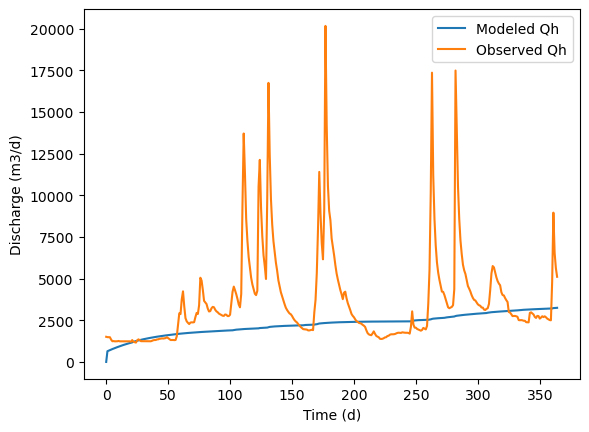

In [60]:
sns.lineplot(result['Qmodel']['Q_h'], label='Modeled Qh')
sns.lineplot(result['Q_obs'], label='Observed Qh')
plt.xlabel("Time (d)")
plt.ylabel("Discharge (m3/d)")

<BarContainer object of 1461 artists>

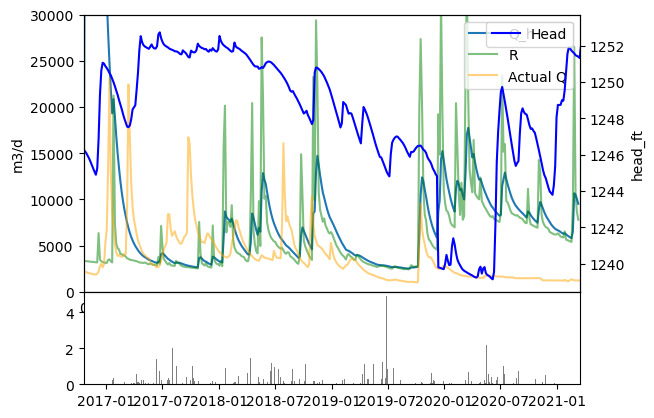

In [41]:
fig, ax = plt.subplots(2,1, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0},)
p_ax = ax[1]
ax = ax[0]
twin_ax = ax.twinx()
sns.lineplot(x=range(len(Q_h)), y=Q_h, ax=ax, label = "Q_h")
sns.lineplot(x=range(len(R)), y=R, ax=ax, color = 'green', label = "R", alpha = 0.5)
sns.lineplot(q['m3/d'], ax=ax, color = 'orange', label = "Actual Q", alpha = 0.5)
ax.set_ylim(0, 30000)
sns.lineplot(h['head_ft'], ax=twin_ax, color = 'blue', label = "Head")
plt.xlim(0,365)
p_ax.bar(p['DATE'], p['PRCP'], color='gray', width=1, label = 'Daily Precip')


In [221]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
p_r = pd.merge(p, r, left_on='DATE', right_on='DATE')
p_r['rolling_PRCP'] = p_r['PRCP'].rolling(window=7).mean()
p_r = p_r.dropna()
q_h = pd.merge(q, h, on='datetime', how='inner').dropna()
X =p_r['rolling_PRCP'].values.reshape(-1, 1)
# X = q_h[['dh_dt', 'dQ_dt']].values
y = p_r['m3/d'].values

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=np.log(q_h['dh_dt']),
            y=np.log(q_h['dQ_dt']),
            z=q_h['head_ft'],
            mode='markers',
            marker=dict(size=4)
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title="dh/dt",
        yaxis_title="dQ/dt",
        zaxis_title="head (ft)"
    ),
    width=800,
    height=600
)

fig.show()
